### 공간 주파수: 공간 상에서 화소 밝기의 변화율
- 고주파 영역: 화소 밝기가 급변하는 영역( 주로 경계)
- 저주파 영역: 화소 밝기의 변화가 거의 없거나 점진적으로 변화하는 영역(주로 배경)

In [1]:
import cv2
import numpy as np
from PIL import Image

def show(image):
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return Image.fromarray(rgb)

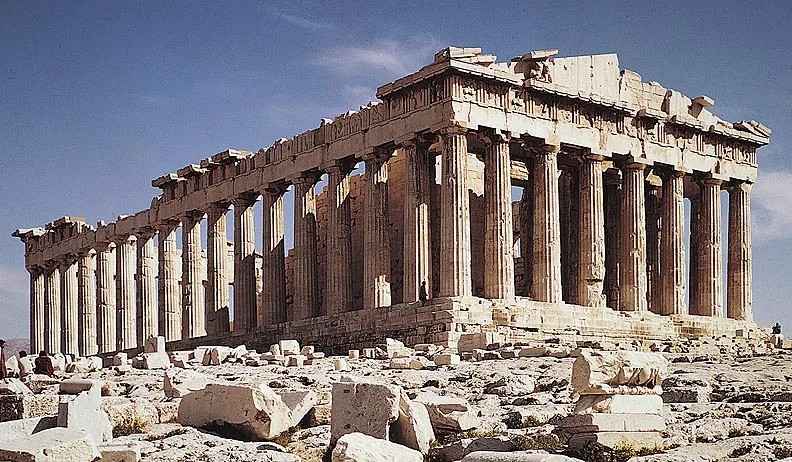

In [3]:
src = cv2.imread('../data/temple.webp')
show(src)

### Spacial Filtering (공간 필터링)
- 인접화소들의 값을 참조하여 화소의 값을 변경하는 처리
- 컨볼루션(convolution): 중심 화소의 값을 인접 화소값들의 가중 합으로 대체하는 연산(가중치 배열 = 커널(kernel))

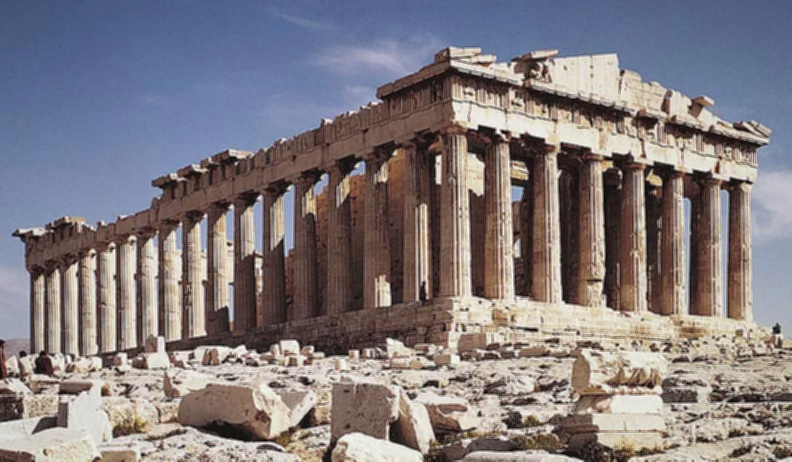

In [4]:
# 평균값 필터링
# 주변 픽셀의 평균으로 채워서 흐리게(blur) 만듦
kernel = np.array([[1/9, 1/9, 1/9], 
                   [1/9, 1/9, 1/9], 
                   [1/9, 1/9, 1/9]], dtype=np.float32)
dst = cv2.filter2D(src, -1, kernel)
show(dst)

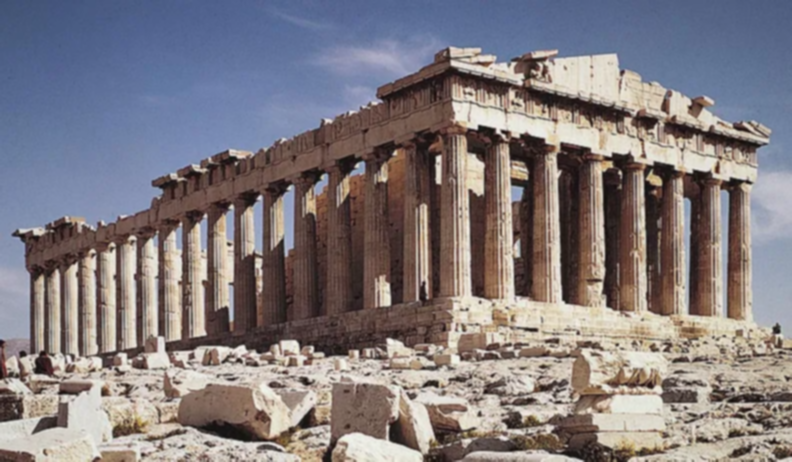

In [ ]:
# 가우시안 블러링 Gaussian Blurring
# 이미지를 흐리게(blur) 만드는 방법
# 가우시안 함수(=통계의 정규 분포)를 이용 → 가운데는 많이, 주변은 적게 반영
blur = cv2.GaussianBlur(src, (5, 5), 0)
show(blur)

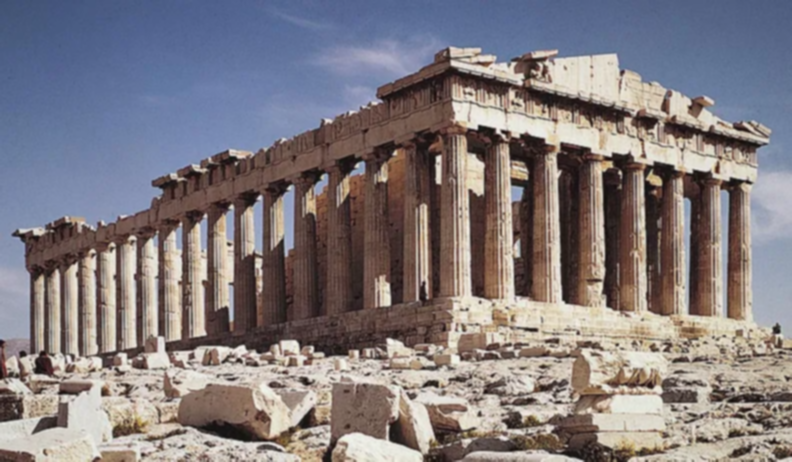

In [6]:
# 커널을 직접 구하기
kernel = cv2.getGaussianKernel(5, 0)
kernel = kernel * kernel.T
kernel = kernel / np.sum(kernel)
dst = cv2.filter2D(src, -1, kernel)
show(dst)

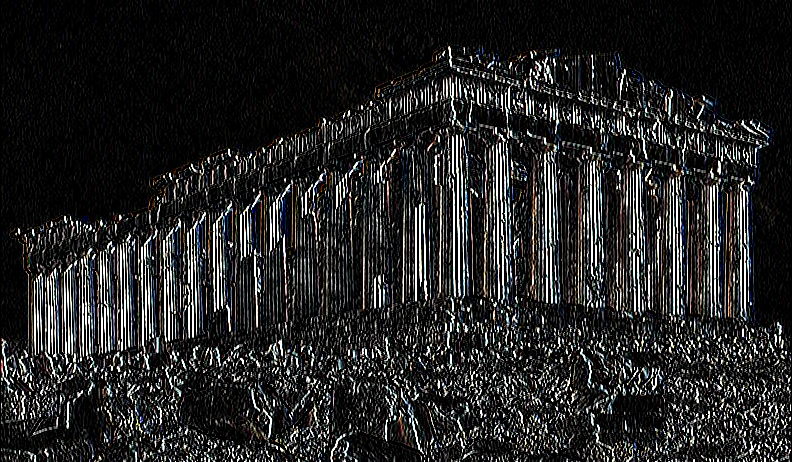

In [ ]:
# 수직 성분의 추출
# 왼쪽 픽셀과 오른쪽 픽셀의 차이 계산
# 수평 방향으로 밝기가 변할 때 결과값이 커짐
kernel = np.array([[-1, 0, 1], 
                   [-1, 0, 1], 
                   [-1, 0, 1]], dtype=np.float32)
dst = cv2.filter2D(src, -1, kernel)
show(dst)

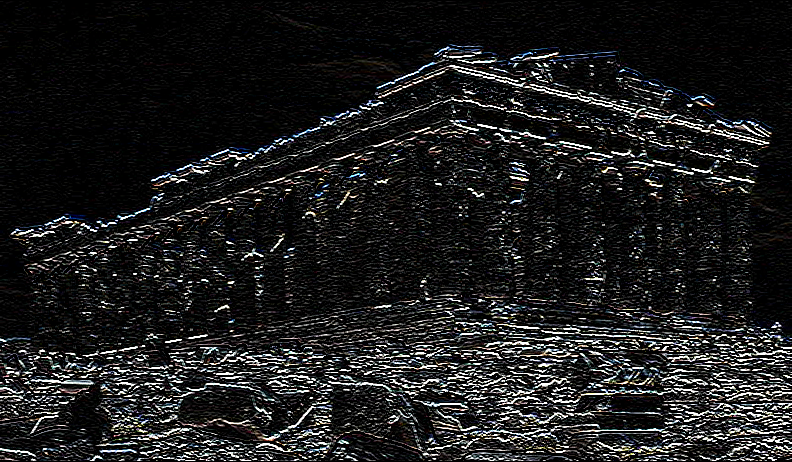

In [8]:
# # 수평 성분의 추출
# # 위쪽 픽셀과 아래쪽 픽셀의 차이 계산
# 수직 방향으로 밝기가 변할 때 결과값이 커짐
kernel = np.array([[ 1,  1,  1], 
                   [ 0,  0,  0], 
                   [-1, -1, -1]], dtype=np.float32)
dst = cv2.filter2D(src, -1, kernel)
show(dst)

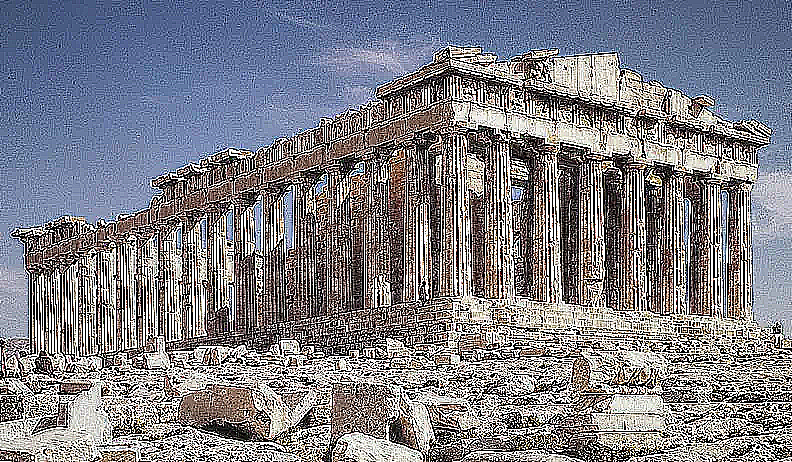

In [9]:
# Sharpening
# 주변 픽셀들과의 밝기 차이를 과장 -> 날카롭게 만드는 효과(blur의 반대)
# 사진을 선명하게 만들 수 있지만, 노이즈도 증가한다
kernel = np.array([[-1, -1, -1], 
                   [-1,  9, -1], 
                   [-1, -1, -1]], dtype=np.float32)
dst = cv2.filter2D(src, -1, kernel)
show(dst)

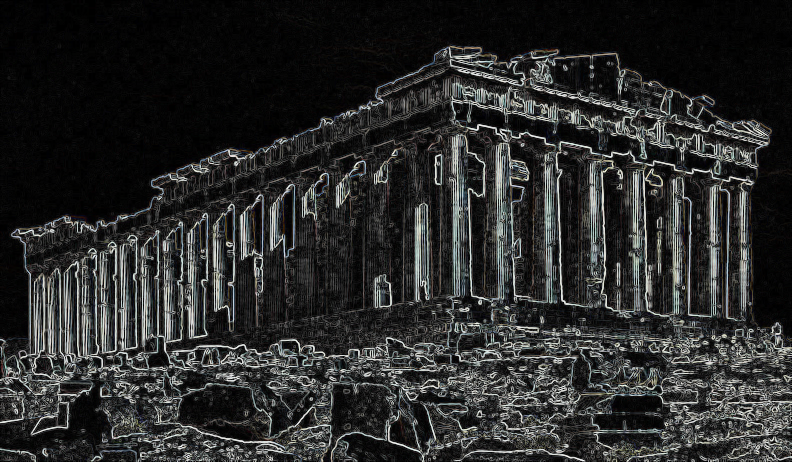

In [11]:
# 소벨 커널 Sobel kernel
# 경계선(edge) 검출을 위한 커널
sobelx = cv2.Sobel(src, cv2.CV_64F, 1, 0, ksize=3) # x 방향의 경계선 검출
sobely = cv2.Sobel(src, cv2.CV_64F, 0, 1, ksize=3) # y 방향의 경계선 검출

sobel_magnitude = cv2.magnitude(sobelx, sobely) # 두 방향의 경계선을 하나로 결합
sobel_result = cv2.normalize(sobel_magnitude, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U) # 정규화
show(sobel_result) # 시각화

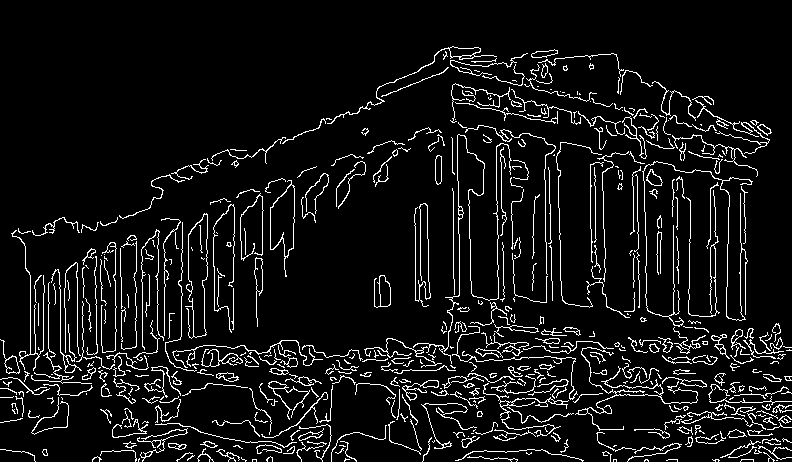

In [ ]:
# 케니 에지 검출 Canny edge detection
# 소벨 커널을 바탕으로 만든 경계선 검출 알고리즘
gray = cv2.cvtColor(src, cv2.COLOR_BGR2GRAY) # 그레이스케일로 변환

# Otsu의 이진화로 상한값 계산
upper, ret = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU) 
lower = upper / 2 # 하한값은 보통 상한값의 1/2 또는 1/3 사용

# 경계선은 밝기가 급변하는 부분 -> 고주파 검출에 해당
# 이미지의 노이즈도 고주파 -> 경계선으로 잘못 검출될 수 있음 -> 가우시안 블러 적용(low-pass filter)
blur = cv2.GaussianBlur(gray, (9, 9), 0) # 가우시안 블러 적용

edges = cv2.Canny(blur, upper, lower)
show(edges) # Canny 엣지 검출 결과 출력